<a href="https://colab.research.google.com/github/JaiShankar14/Jaishankar-Ganesan.github.io/blob/main/Autonomus_Rover_YOLO_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ultralytics kaggle opencv-python tqdm pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.1 MB/s eta 0:00:00


In [2]:
!pip install -q kagglehub
!pip install -q opencv-python tqdm

In [3]:
# import kagglehub
# from pathlib import Path

# dataset_path = kagglehub.dataset_download(
#     "vipoooool/new-plant-diseases-dataset"
# )

# dataset_path = Path(dataset_path)

# print(dataset_path)

In [4]:
# print(dataset_path)

In [5]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [01:21<00:00, 35.6MB/s]



In [6]:
!unzip -q new-plant-diseases-dataset.zip -d /content/

In [7]:
import os

SOURCE = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

print(os.listdir(SOURCE))

['train', 'valid']


Create Yolo Folder structure

In [8]:
import os

OUTPUT = "/content/PlantYOLO"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(OUTPUT, folder), exist_ok=True)

print("Folders created.")

Folders created.


In [9]:
train_dir = os.path.join(SOURCE, "train")

classes = sorted(os.listdir(train_dir))

class_to_id = {
    name: idx
    for idx, name in enumerate(classes)
}

print("Total Classes:", len(classes))

print(classes[:10])

Total Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


Convert the data into YOLO dataset format

In [10]:
import shutil
from glob import glob
from tqdm import tqdm

def convert(split_input, split_output):

    source_folder = os.path.join(SOURCE, split_input)

    image_output = os.path.join(OUTPUT, "images", split_output)

    label_output = os.path.join(OUTPUT, "labels", split_output)

    for cls in tqdm(classes):

        cls_id = class_to_id[cls]

        images = []

        for ext in ["*.jpg","*.JPG","*.jpeg","*.JPEG","*.png"]:
            images.extend(glob(os.path.join(source_folder, cls, ext)))

        for img in images:

            filename = os.path.basename(img)

            shutil.copy(img, os.path.join(image_output, filename))

            label_name = os.path.splitext(filename)[0] + ".txt"

            with open(os.path.join(label_output, label_name), "w") as f:
                f.write(f"{cls_id} 0.5 0.5 1.0 1.0")

In [11]:
convert("train", "train")
convert("valid", "val")

print("Conversion Finished")

100%|██████████| 38/38 [00:02<00:00, 14.53it/s]

Conversion Finished


In [12]:
import yaml

data = {
    "path": OUTPUT,
    "train": "images/train",
    "val": "images/val",
    "nc": len(classes),
    "names": classes
}

with open("/content/plant.yaml","w") as f:
    yaml.dump(data, f)

print(data)

{'path': '/content/PlantYOLO', 'train': 'images/train', 'val': 'images/val', 'nc': 38, 'names': ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'To

In [13]:
print(os.listdir("/content/PlantYOLO/images/train")[:5])

print(os.listdir("/content/PlantYOLO/labels/train")[:5])

['413bc2e9-eb2a-48fd-ba65-48b5121fd85c___RS_HL 4200.JPG', 'RS_Rust 1850_flipLR.JPG', '5786dc07-0a0f-460b-896b-2bb4a240679e___RS_GLSp 7282.JPG', 'd7f1e802-0b8e-4cba-88b4-e61328322cac___RS_Erly.B 8222.JPG', '41dc26ff-7912-4bda-9ff5-e138dd3c7131___Rut._Bact.S 3491.JPG']
['ca6362b2-b680-4348-a795-3bc37275e70f___GHLB2 Leaf 79.txt', 'ea9d49e5-e3ee-4429-8592-4ce9a910376f___NREC_B.Spot 1821_180deg.txt', 'e0e7eca2-7bfa-40c8-b622-9fcdbdb43369___CREC_HLB 7783.txt', '143e8197-a7d6-48a7-8e9e-05cd7dd1323f___FAM_B.Rot 0421_flipLR.txt', '6d4ccc3a-c410-4d67-8858-e411ad1c4486___FREC_Pwd.M 5007_flipLR.txt']


Check Train and Validation Directory

In [14]:
import os

path = "/content/PlantYOLO"

for item in os.listdir(path):
    print(item)

labels
images


In [15]:
import os

path = "/content/PlantYOLO"

for root, dirs, files in os.walk(path):
    print(f"\n📂 {root}")

    for d in dirs:
        print(f"  📁 {d}")

    # for f in files:
    #     print(f"  📄 {f}")


📂 /content/PlantYOLO
  📁 labels
  📁 images

📂 /content/PlantYOLO/labels
  📁 train
  📁 val

📂 /content/PlantYOLO/labels/train

📂 /content/PlantYOLO/labels/val

📂 /content/PlantYOLO/images
  📁 train
  📁 val

📂 /content/PlantYOLO/images/train

📂 /content/PlantYOLO/images/val


In [16]:
import os

path = "/content/PlantYOLO"

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff", ".webp")
label_extensions = (".txt",)

for root, dirs, files in os.walk(path):
    print(f"\n📂 {root}")

    for d in dirs:
        dir_path = os.path.join(root, d)

        image_count = 0
        label_count = 0

        for f in os.listdir(dir_path):
            file_path = os.path.join(dir_path, f)

            if os.path.isfile(file_path):
                if f.lower().endswith(image_extensions):
                    image_count += 1
                elif f.lower().endswith(label_extensions):
                    label_count += 1

        print(f"  📁 {d}")
        print(f"     Images : {image_count}")
        print(f"     Labels : {label_count}")


📂 /content/PlantYOLO
  📁 labels
     Images : 0
     Labels : 0
  📁 images
     Images : 0
     Labels : 0

📂 /content/PlantYOLO/labels
  📁 train
     Images : 0
     Labels : 70295
  📁 val
     Images : 0
     Labels : 17572

📂 /content/PlantYOLO/labels/train

📂 /content/PlantYOLO/labels/val

📂 /content/PlantYOLO/images
  📁 train
     Images : 70295
     Labels : 0
  📁 val
     Images : 17572
     Labels : 0

📂 /content/PlantYOLO/images/train

📂 /content/PlantYOLO/images/val


TRAIN YOLO-v8-Nan model

In [17]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [19]:
results = model.train(
    data="/content/plant.yaml",
    epochs=30,
    imgsz=640,
    batch=32,
    workers=2,
    device=0,
    project="/content/runs",
    name="plant_disease"
)

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/plant.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plant_disease, nbs=64, nms=F

Validation of the Model

In [20]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 3,013,058 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 712.6±305.8 MB/s, size: 18.3 KB)
val: Scanning /content/PlantYOLO/labels/val.cache... 17572 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17572/17572 5.3Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1099/1099 14.4it/s 1:16
                   all      17572      17572      0.997      0.997      0.995      0.995
    Apple___Apple_scab        504        504      0.999          1      0.995      0.995
     Apple___Black_rot        497        497          1          1      0.995      0.995
Apple___Cedar_apple_rust        440        440      0.999          1      0.995      0.995
       Apple___healthy        502        502          1          1      0.995      0.995
   Blueberry___healthy  

In [21]:
print("="*50)
print("Validation Metrics")
print("="*50)

print(f"mAP@50      : {metrics.box.map50:.4f}")
print(f"mAP@50-95   : {metrics.box.map:.4f}")
print(f"Precision   : {metrics.box.mp:.4f}")
print(f"Recall      : {metrics.box.mr:.4f}")

Validation Metrics
mAP@50      : 0.9949
mAP@50-95   : 0.9949
Precision   : 0.9971
Recall      : 0.9974


In [22]:
print("\nPer-Class mAP (50-95)")
print("-" * 60)

for i, cls in enumerate(classes):
    print(f"{i:2d} {cls:40s}: {metrics.box.maps[i]:.4f}")


Per-Class mAP (50-95)
------------------------------------------------------------
 0 Apple___Apple_scab                      : 0.9950
 1 Apple___Black_rot                       : 0.9950
 2 Apple___Cedar_apple_rust                : 0.9950
 3 Apple___healthy                         : 0.9950
 4 Blueberry___healthy                     : 0.9950
 5 Cherry_(including_sour)___Powdery_mildew: 0.9950
 6 Cherry_(including_sour)___healthy       : 0.9950
 7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 0.9945
 8 Corn_(maize)___Common_rust_             : 0.9950
 9 Corn_(maize)___Northern_Leaf_Blight     : 0.9946
10 Corn_(maize)___healthy                  : 0.9950
11 Grape___Black_rot                       : 0.9950
12 Grape___Esca_(Black_Measles)            : 0.9950
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 0.9950
14 Grape___healthy                         : 0.9950
15 Orange___Haunglongbing_(Citrus_greening): 0.9950
16 Peach___Bacterial_spot                  : 0.9950
17 Peach___healthy  

Best Model Validation

In [23]:
best_model = YOLO("/content/runs/plant_disease/weights/best.pt")

In [24]:
best_model.predict(
    source="/content/PlantYOLO/images/val",
    save=True,
    conf=0.25
)

Streaming output truncated to the last 5000 lines.
image 12575/17572 /content/PlantYOLO/images/val/bc7769cc-805e-42ef-bbcf-0c134ff03276___FREC_Scab 2909_new30degFlipLR.JPG: 640x640 1 Apple___Apple_scab, 6.8ms
image 12576/17572 /content/PlantYOLO/images/val/bc825946-3ee5-4269-8ba4-202afc766654___RS_HL 0368.JPG: 640x640 1 Tomato___healthy, 6.9ms
image 12577/17572 /content/PlantYOLO/images/val/bc82bae8-9be5-4035-afd4-35332a362030___Mary_HL 6384.JPG: 640x640 1 Raspberry___healthy, 7.9ms
image 12578/17572 /content/PlantYOLO/images/val/bc837901-a8c4-4dc2-991c-3a467fa234e1___Mary_HL 6385_90deg.JPG: 640x640 1 Raspberry___healthy, 7.7ms
image 12579/17572 /content/PlantYOLO/images/val/bc837901-a8c4-4dc2-991c-3a467fa234e1___Mary_HL 6385_new30degFlipLR.JPG: 640x640 1 Raspberry___healthy, 7.1ms
image 12580/17572 /content/PlantYOLO/images/val/bc863aa7-2cb6-44f1-b060-4cd78237d7a3___FREC_C.Rust 3566_270deg.JPG: 640x640 1 Apple___Cedar_apple_rust, 7.3ms
image 12581/17572 /content/PlantYOLO/images/val/b

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'Apple___Apple_scab', 1: 'Apple___Black_rot', 2: 'Apple___Cedar_apple_rust', 3: 'Apple___healthy', 4: 'Blueberry___healthy', 5: 'Cherry_(including_sour)___Powdery_mildew', 6: 'Cherry_(including_sour)___healthy', 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 8: 'Corn_(maize)___Common_rust_', 9: 'Corn_(maize)___Northern_Leaf_Blight', 10: 'Corn_(maize)___healthy', 11: 'Grape___Black_rot', 12: 'Grape___Esca_(Black_Measles)', 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 14: 'Grape___healthy', 15: 'Orange___Haunglongbing_(Citrus_greening)', 16: 'Peach___Bacterial_spot', 17: 'Peach___healthy', 18: 'Pepper,_bell___Bacterial_spot', 19: 'Pepper,_bell___healthy', 20: 'Potato___Early_blight', 21: 'Potato___Late_blight', 22: 'Potato___healthy', 23: 'Raspberry___healthy', 24: 'Soybean___healthy', 25: 'Squash___Powdery_mil

Loss curve

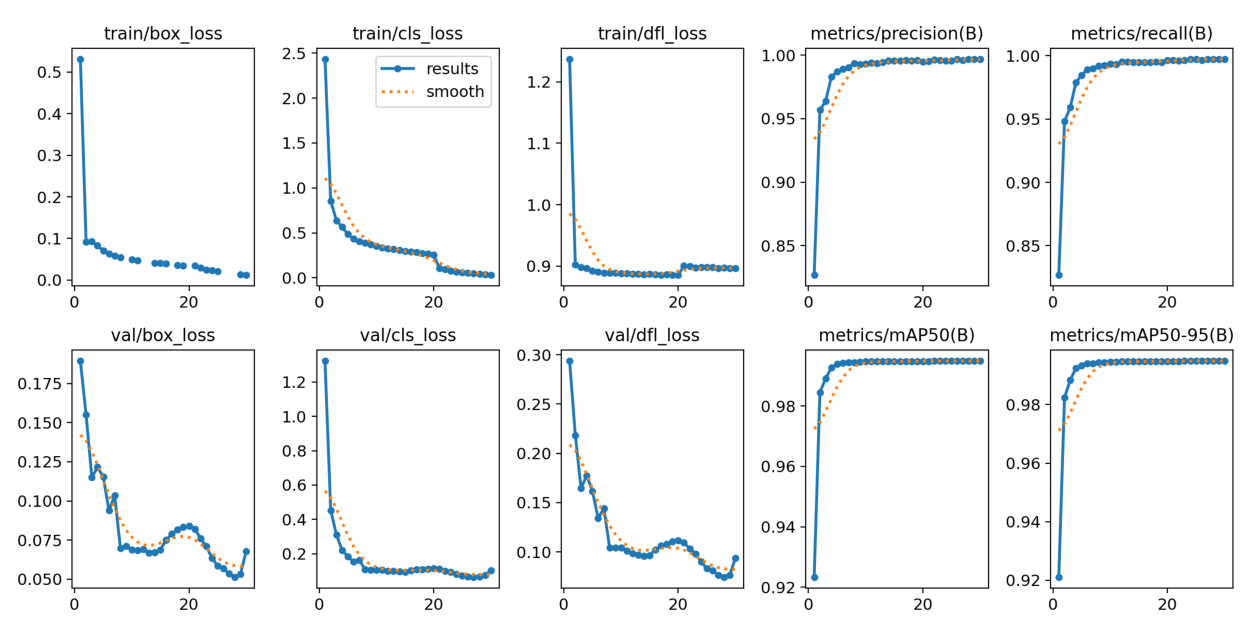

In [25]:
from PIL import Image
import matplotlib.pyplot as plt

# Path to your training results image
results_path = "/content/runs/plant_disease/results.png"

img = Image.open(results_path)

plt.figure(figsize=(16,12))
plt.imshow(img)
plt.axis("off")
plt.show()

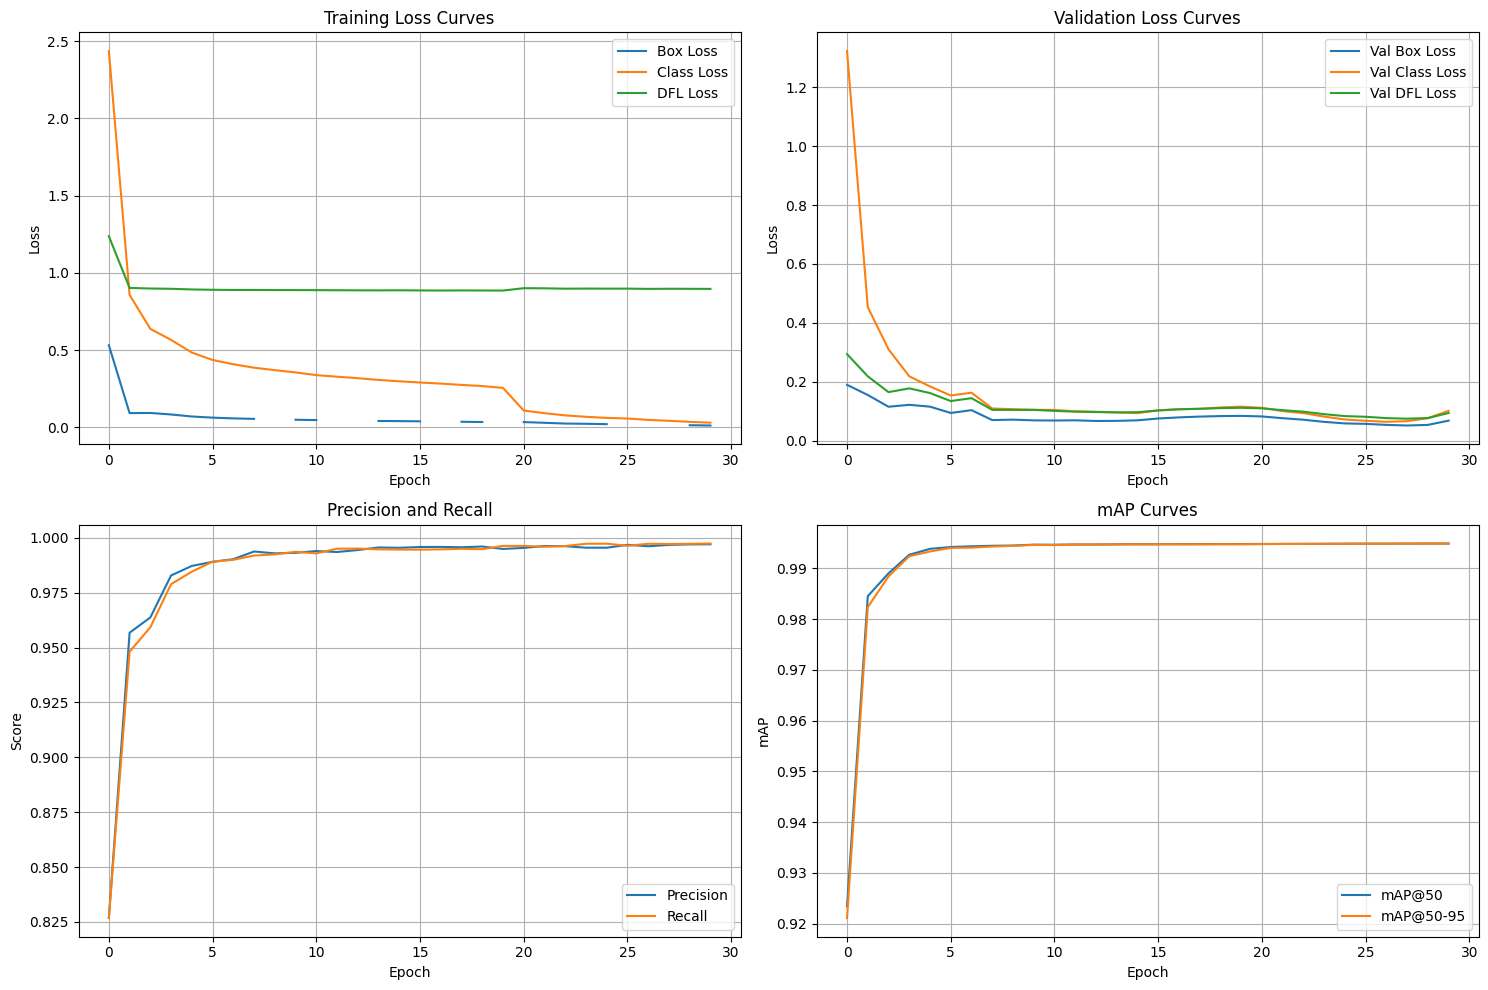

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training history
csv_path = "/content/runs/plant_disease/results.csv"

results = pd.read_csv(csv_path)

# Remove spaces in column names
results.columns = results.columns.str.strip()

plt.figure(figsize=(15,10))

# Loss curves
plt.subplot(2,2,1)
plt.plot(results["train/box_loss"], label="Box Loss")
plt.plot(results["train/cls_loss"], label="Class Loss")
plt.plot(results["train/dfl_loss"], label="DFL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid()

# Validation losses
plt.subplot(2,2,2)
plt.plot(results["val/box_loss"], label="Val Box Loss")
plt.plot(results["val/cls_loss"], label="Val Class Loss")
plt.plot(results["val/dfl_loss"], label="Val DFL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Curves")
plt.legend()
plt.grid()

# Precision and Recall
plt.subplot(2,2,3)
plt.plot(results["metrics/precision(B)"], label="Precision")
plt.plot(results["metrics/recall(B)"], label="Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision and Recall")
plt.legend()
plt.grid()

# mAP curves
plt.subplot(2,2,4)
plt.plot(results["metrics/mAP50(B)"], label="mAP@50")
plt.plot(results["metrics/mAP50-95(B)"], label="mAP@50-95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("mAP Curves")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Inference:
There is a possible corruption of an Image in Validation dataset (spike observed in epoch 35~40)

Check Validity of Validation dataset

In [27]:
import os

image_dir="/content/PlantYOLO/images/val"
label_dir="/content/PlantYOLO/labels/val"

images=set(os.listdir(image_dir))
labels=set(os.listdir(label_dir))

missing=[]

for img in images:
    txt=os.path.splitext(img)[0]+".txt"
    if txt not in labels:
        missing.append(img)

print("Missing labels:",len(missing))
print(missing[:10])

Missing labels: 0
[]


In [28]:
import glob

classes=[]

for file in glob.glob("/content/PlantYOLO/labels/val/*.txt"):
    with open(file) as f:
        for line in f:
            classes.append(int(line.split()[0]))

print(set(classes))

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37}


In [29]:
empty_labels = []

for txt in os.listdir(label_dir):

    path = os.path.join(label_dir, txt)

    if os.path.getsize(path) == 0:
        empty_labels.append(txt)


print("Empty labels:", len(empty_labels))

print(empty_labels[:20])

Empty labels: 0
[]


In [30]:
classes = []

for txt in os.listdir(label_dir):

    with open(os.path.join(label_dir, txt)) as f:

        for line in f:
            cls = int(line.split()[0])
            classes.append(cls)


print("Classes found:")
print(sorted(set(classes)))

Classes found:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]


In [31]:
bad_boxes=[]

for txt in os.listdir(label_dir):

    path=os.path.join(label_dir,txt)

    with open(path) as f:

        for line_num,line in enumerate(f):

            values=line.split()

            if len(values)!=5:
                bad_boxes.append((txt,line_num,"wrong format"))
                continue

            cls,x,y,w,h=map(float,values)

            if not (0<=x<=1 and
                    0<=y<=1 and
                    0<=w<=1 and
                    0<=h<=1):

                bad_boxes.append((txt,line_num,values))


print("Bad boxes:",len(bad_boxes))
print(bad_boxes[:10])

Bad boxes: 0
[]


In [32]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.val(
    data="/content/plant.yaml",
    split="val",
    plots=True
)

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 818.0±423.4 MB/s, size: 19.0 KB)
val: Scanning /content/PlantYOLO/labels/val.cache... 17572 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17572/17572 5.3Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1099/1099 12.7it/s 1:27
                   all      17572      17572     0.0132      0.346    0.00848    0.00431
                person        504        504    0.00448      0.984      0.018     0.0116
               bicycle        497        497     0.0527      0.103    0.00663    0.00447
                   car        440        440     0.0153      0.464    0.00815    0.00423
            motorcycle        502        502     0.0202     0.0837     0.0018    0.00111
              airplane  

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f261c403320>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,  

Save the best model

In [33]:
import os

for root, dirs, files in os.walk("/content/runs"):
    for file in files:
        if file == "best.pt":
            print(os.path.join(root, file))

/content/runs/plant_disease/weights/best.pt


In [34]:
from google.colab import files

files.download("/content/runs/plant_disease/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Validation of the dataset

In [35]:
print(type(results))

<class 'pandas.core.frame.DataFrame'>


In [39]:
print("mAP50     :", metrics.box.map50)
print("mAP50-95  :", metrics.box.map)
print("Precision :", metrics.box.mp)
print("Recall    :", metrics.box.mr)

mAP50     : 0.9949125688454297
mAP50-95  : 0.9949124587375239
Precision : 0.9970863436274655
Recall    : 0.9973913420844496


In [40]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/runs/plant_disease/weights/best.pt")

# Run prediction on validation images
pred_results = model.predict(
    source="/content/PlantYOLO/images/val",
    conf=0.25
)

for i, result in enumerate(pred_results[:5]):

    print("=" * 60)
    print(f"Image {i+1}")
    print("Image Path:", result.path)

    print("Number of detections:", len(result.boxes))

    for box in result.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        xyxy = box.xyxy.cpu().numpy()

        print("Class :", model.names[cls])
        print("Conf  :", conf)
        print("xyxy  :", xyxy)
        print()

Streaming output truncated to the last 5000 lines.
image 12614/17572 /content/PlantYOLO/images/val/bcf169b0-dea7-49eb-b976-4a2d1f36c574___RS_Early.B 7870_180deg.JPG: 640x640 1 Potato___Early_blight, 7.3ms
image 12615/17572 /content/PlantYOLO/images/val/bcf2a4c7-5e73-4443-b39c-74fd6895afb5___GH_HL Leaf 248.1.JPG: 640x640 1 Tomato___healthy, 6.6ms
image 12616/17572 /content/PlantYOLO/images/val/bcf2f5b8-8788-4ba2-a510-1174c00e76e3___Matt.S_CG 1619.JPG: 640x640 1 Tomato___Septoria_leaf_spot, 6.6ms
image 12617/17572 /content/PlantYOLO/images/val/bcf52398-58a1-414e-afd7-ba7b0e26d66e___RS_L.Scorch 1110_flipLR.JPG: 640x640 1 Strawberry___Leaf_scorch, 6.6ms
image 12618/17572 /content/PlantYOLO/images/val/bcf56f7d-d584-4fed-b42e-5cbf3b8707b7___JR_B.Spot 3197.JPG: 640x640 1 Pepper,_bell___Bacterial_spot, 7.5ms
image 12619/17572 /content/PlantYOLO/images/val/bd00b453-4675-428d-ad49-ade22d21ae9d___RS_NLB 3787.JPG: 640x640 1 Corn_(maize)___Northern_Leaf_Blight, 7.4ms
image 12620/17572 /content/Plan

In [41]:
import pandas as pd

predictions = []

for result in pred_results:

    for box in result.boxes:

        cls = int(box.cls[0])
        conf = float(box.conf[0])

        predictions.append({
            "Image": result.path.split("/")[-1],
            "Class": model.names[cls],
            "Confidence": conf
        })

df = pd.DataFrame(predictions)

print(df)

                                                   Image  \
0      00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...   
1      00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...   
2      00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...   
3      00090b0f-c140-4e77-8d20-d39f67b75fcc___FAM_B.R...   
4      000ec6ea-9063-4c33-8abe-d58ca8a88878___PSU_CG ...   
...                                                  ...   
17637  ffe53930-c98f-4c81-b82c-3eeab5da42a5___R.S_HL ...   
17638  ffef8a3b-3e8a-4c24-a27e-64c41708f7a0___RS_Earl...   
17639  fff3aeaf-d4ae-4f3a-86d9-79237d07270f___Com.G_S...   
17640  fff606e6-7949-44cf-90d3-9507d2a97cfe___RS_HL 4...   
17641  fff99912-2321-46f9-9f81-20f0e9296776___FAM_B.M...   

                                               Class  Confidence  
0                                 Apple___Apple_scab    0.995350  
1                                 Apple___Apple_scab    0.996670  
2                                 Apple___Apple_scab    0.997132  
3          

Test single image

In [42]:
from glob import glob

test_img = glob("/content/PlantYOLO/images/val/*.jpg")[0]

print(test_img)

/content/PlantYOLO/images/val/87f58832-076a-41b1-b8d0-181077b5f478___R.S_HL 5560 copy 2_flipLR.jpg


In [43]:
best_model.predict(
    source=test_img,
    save=True,
    show=False
)


image 1/1 /content/PlantYOLO/images/val/87f58832-076a-41b1-b8d0-181077b5f478___R.S_HL 5560 copy 2_flipLR.jpg: 640x640 1 Corn_(maize)___healthy, 8.8ms
Speed: 2.8ms preprocess, 8.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'Apple___Apple_scab', 1: 'Apple___Black_rot', 2: 'Apple___Cedar_apple_rust', 3: 'Apple___healthy', 4: 'Blueberry___healthy', 5: 'Cherry_(including_sour)___Powdery_mildew', 6: 'Cherry_(including_sour)___healthy', 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 8: 'Corn_(maize)___Common_rust_', 9: 'Corn_(maize)___Northern_Leaf_Blight', 10: 'Corn_(maize)___healthy', 11: 'Grape___Black_rot', 12: 'Grape___Esca_(Black_Measles)', 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 14: 'Grape___healthy', 15: 'Orange___Haunglongbing_(Citrus_greening)', 16: 'Peach___Bacterial_spot', 17: 'Peach___healthy', 18: 'Pepper,_bell___Bacterial_spot', 19: 'Pepper,_bell___healthy', 20: 'Potato___Early_blight', 21: 'Potato___Late_blight', 22: 'Potato___healthy', 23: 'Raspberry___healthy', 24: 'Soybean___healthy', 25: 'Squash___Powdery_mil

Validation w.r.t scikit-learn

In [46]:
from ultralytics import YOLO
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import os
import numpy as np



model = YOLO("/content/best (6).pt")



image_dir = "/content/PlantYOLO/images/val"
label_dir = "/content/PlantYOLO/labels/val"


image_files = sorted(os.listdir(image_dir))



y_true = []
y_pred = []

missing_labels = []
no_detection_images = []



for image_name in image_files:

    image_path = os.path.join(image_dir, image_name)


    label_name = os.path.splitext(image_name)[0] + ".txt"

    label_path = os.path.join(
        label_dir,
        label_name
    )


    # Skip images without labels
    if not os.path.exists(label_path):
        missing_labels.append(image_name)
        continue


    with open(label_path, "r") as f:

        lines = f.readlines()


    # Skip empty label files
    if len(lines) == 0:
        continue


    # First object class
    gt_class = int(lines[0].split()[0])

    y_true.append(gt_class)

    results = model.predict(
        image_path,
        conf=0.25,
        imgsz=640,
        verbose=False
    )


    boxes = results[0].boxes


    if len(boxes) > 0:

        # Take highest confidence prediction
        confs = boxes.conf.cpu().numpy()

        best_idx = np.argmax(confs)

        pred_class = int(
            boxes.cls[best_idx]
        )

    else:

        # No object detected
        pred_class = -1
        no_detection_images.append(image_name)


    y_pred.append(pred_class)



print("================================")
print("Evaluation completed")
print("================================")

print("Total images:", len(image_files))
print("Evaluated images:", len(y_true))

print("Missing labels:", len(missing_labels))
print("No detections:", len(no_detection_images))


print("\nAccuracy:")
print(
    accuracy_score(
        y_true,
        y_pred
    )
)


print("\nPrecision:")
print(
    precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)


print("\nRecall:")
print(
    recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)


print("\nF1 Score:")
print(
    f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)


print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)


print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_true,
        y_pred
    )
)


if len(missing_labels) > 0:

    print("\nMissing label examples:")
    for x in missing_labels[:10]:
        print(x)


if len(no_detection_images) > 0:

    print("\nImages with no detection examples:")
    for x in no_detection_images[:10]:
        print(x)

Evaluation completed
Total images: 17572
Evaluated images: 17572
Missing labels: 0
No detections: 0

Accuracy:
0.9972683815160482

Precision:
0.9972787853614153

Recall:
0.9972683815160482

F1 Score:
0.997265318317929

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       504
           1       1.00      1.00      1.00       497
           2       1.00      1.00      1.00       440
           3       1.00      1.00      1.00       502
           4       1.00      1.00      1.00       454
           5       1.00      1.00      1.00       421
           6       1.00      1.00      1.00       456
           7       0.99      0.96      0.98       410
           8       0.99      1.00      1.00       477
           9       0.97      0.99      0.98       477
          10       1.00      1.00      1.00       465
          11       1.00      1.00      1.00       472
          12       1.00      1.00      1.00       480
 

In [47]:
print("="*60)
print("OVERALL VALIDATION METRICS")
print("="*60)

print(f"Accuracy           : {accuracy_score(y_true,y_pred):.4f}")

print(f"Precision (Macro)  : {precision_score(y_true,y_pred,average='macro',zero_division=0):.4f}")
print(f"Recall (Macro)     : {recall_score(y_true,y_pred,average='macro',zero_division=0):.4f}")
print(f"F1-score (Macro)   : {f1_score(y_true,y_pred,average='macro',zero_division=0):.4f}")

print()

print(f"Precision (Micro)  : {precision_score(y_true,y_pred,average='micro'):.4f}")
print(f"Recall (Micro)     : {recall_score(y_true,y_pred,average='micro'):.4f}")
print(f"F1-score (Micro)   : {f1_score(y_true,y_pred,average='micro'):.4f}")

print()

print(f"Precision (Weighted): {precision_score(y_true,y_pred,average='weighted'):.4f}")
print(f"Recall (Weighted)   : {recall_score(y_true,y_pred,average='weighted'):.4f}")
print(f"F1-score (Weighted) : {f1_score(y_true,y_pred,average='weighted'):.4f}")

OVERALL VALIDATION METRICS
Accuracy           : 0.9973
Precision (Macro)  : 0.9972
Recall (Macro)     : 0.9972
F1-score (Macro)   : 0.9972

Precision (Micro)  : 0.9973
Recall (Micro)     : 0.9973
F1-score (Micro)   : 0.9973

Precision (Weighted): 0.9973
Recall (Weighted)   : 0.9973
F1-score (Weighted) : 0.9973


In [51]:
classes = list(model.names.values())

print(len(classes))
print(classes)

38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target

In [52]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    labels=range(len(classes)),
    target_names=classes,
    digits=4,
    zero_division=0
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000       504
                                 Apple___Black_rot     1.0000    1.0000    1.0000       497
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000       440
                                   Apple___healthy     1.0000    1.0000    1.0000       502
                               Blueberry___healthy     0.9956    1.0000    0.9978       454
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       421
                 Cherry_(including_sour)___healthy     0.9978    0.9978    0.9978       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9900    0.9634    0.9765       410
                       Corn_(maize)___Common_rust_     0.9917    1.0000    0.9958       477
               Corn_(maize)___Northern_Leaf_Blight     0.9731    0.9874    0.98